In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle
from tensorflow.keras.optimizers import Adam

In [3]:
tfidf_matrix= np.load("../data/tfidf_matrix.npy")

with open("../data/tfidf_vectorizer.pkl", "rb") as f:
    tfid_vectorizer= pickle.load(f)

categories_df= pd.read_csv("../data/CategoryLabels.csv")

In [4]:
tfidf_matrix.shape
categories_df.shape
categories_df.head()

,Category
0,HR
1,HR
2,HR
3,HR
4,HR


In [5]:
encoder= LabelEncoder()

In [6]:
categories_transformed= encoder.fit_transform(categories_df["Category"])

In [7]:
with open("../data/Categories_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [8]:
print(categories_transformed[:5])
print(encoder.classes_)

[19 19 19 19 19]
['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [9]:
X= tfidf_matrix.copy()
y= categories_transformed.copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape)
print(X_test.shape)


(1986, 8000)
(497, 8000)


In [10]:
model= Sequential([
    Dense(512, input_dim=8000, activation= 'relu'),
    Dropout(0.5),
    Dense(256, activation= 'relu'),
    Dropout(0.5),
    Dense(24, activation= 'softmax')
])

d:\Github-Repos\AI-Resume-Analyzer\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer= Adam(learning_rate= 0.001), 
              loss= 'sparse_categorical_crossentropy', 
              metrics= ['accuracy'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     4,096,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,234,008 (16.15 MB)

 Trainable params: 4,234,008 (16.15 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history= model.fit(
    X_train, y_train,
    epochs= 20,
    batch_size= 32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose= 1
    )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1823 - loss: 3.0218 - val_accuracy: 0.4668 - val_loss: 2.5806
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4642 - loss: 2.0963 - val_accuracy: 0.5352 - val_loss: 1.6905
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6264 - loss: 1.3706 - val_accuracy: 0.6137 - val_loss: 1.4084
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7860 - loss: 0.8707 - val_accuracy: 0.6298 - val_loss: 1.3135
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8832 - loss: 0.5397 - val_accuracy: 0.6278 - val_loss: 1.2623
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9416 - loss: 0.3035 - val_accuracy: 0.6579 - val_loss: 1.2564
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9743 - loss: 0.1817 - val_accuracy: 0.6519 - val_loss: 1.2543
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9839 - loss: 0.1094 - val_accuracy: 0.6579 - v

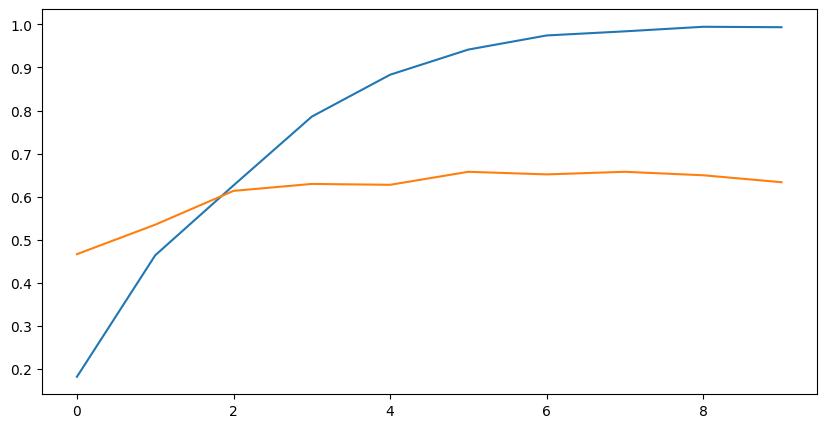

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize= (10,5))
plt.plot(history.history['accuracy'], label= 'Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')

In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Create model
model_svm = LinearSVC()

# Train
model_svm.fit(X_train, y_train)

# Predict
y_pred = model_svm.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7022132796780685


In [18]:
with open('../data/svm_model.pkl', 'wb')as f:
    pickle.dump(model_svm, f)